In [ ]:
%pip install gymnasium torch matplotlib numpy

In [ ]:
import random
from collections import deque

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# Configuração de semente para reprodutibilidade dos testes
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

  Using cached gymnasium-1.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached farama_notifications-0.0.6-py3-none-any.whl.metadata (729 bytes)
  Using cached filelock-3.32.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached gymnasium-1.3.0-py3-none-any.whl (953 kB)
   ---------------------------------------- 0.0/122.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.0 MB 1.3 MB/s eta 0:01:36
   ---------------------------------------- 0.1/122.0 MB 1.3 MB/s eta 0:01:33
   ---------------------------------------- 0.2/122.0

In [3]:
class QNetwork(nn.Module):

  def __init__(self, state_dim, action_dim):
    super(QNetwork, self).__init__()
    self.fc = nn.Sequential(
        nn.Linear(state_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, action_dim),
    )

  def forward(self, x):
    return self.fc(x)

In [5]:
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

agent = DQNAgent(state_dim, action_dim)
episodes = 300
target_update_freq = 10
scores = []

print("Iniciando treinamento do DQN no CartPole-v1...\n")

for episode in range(1, episodes + 1):
  state, _ = env.reset(seed=SEED + episode)
  total_reward = 0
  done = False

  while not done:
    action = agent.select_action(state)
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    agent.memory.push(state, action, reward, next_state, float(done))
    agent.train_step()

    state = next_state
    total_reward += reward

  scores.append(total_reward)

  # Atualização periódica da Target Network
  if episode % target_update_freq == 0:
    agent.update_target_network()

  if episode % 20 == 0:
    avg_score = np.mean(scores[-20:])
    print(
        f"Episódio {episode}/{episodes} | Pontuação Média (Últimos 20):"
        f" {avg_score:.1f} | Epsilon: {agent.epsilon:.2f}"
    )

env.close()

Iniciando treinamento do DQN no CartPole-v1...

Episódio 20/300 | Pontuação Média (Últimos 20): 14.6 | Epsilon: 0.32
Episódio 40/300 | Pontuação Média (Últimos 20): 10.8 | Epsilon: 0.11
Episódio 60/300 | Pontuação Média (Últimos 20): 81.2 | Epsilon: 0.01
Episódio 80/300 | Pontuação Média (Últimos 20): 208.3 | Epsilon: 0.01
Episódio 100/300 | Pontuação Média (Últimos 20): 199.6 | Epsilon: 0.01
Episódio 120/300 | Pontuação Média (Últimos 20): 165.5 | Epsilon: 0.01
Episódio 140/300 | Pontuação Média (Últimos 20): 213.5 | Epsilon: 0.01
Episódio 160/300 | Pontuação Média (Últimos 20): 173.8 | Epsilon: 0.01
Episódio 180/300 | Pontuação Média (Últimos 20): 251.9 | Epsilon: 0.01
Episódio 200/300 | Pontuação Média (Últimos 20): 319.2 | Epsilon: 0.01
Episódio 220/300 | Pontuação Média (Últimos 20): 271.6 | Epsilon: 0.01
Episódio 240/300 | Pontuação Média (Últimos 20): 240.5 | Epsilon: 0.01
Episódio 260/300 | Pontuação Média (Últimos 20): 310.9 | Epsilon: 0.01
Episódio 280/300 | Pontuação Média (

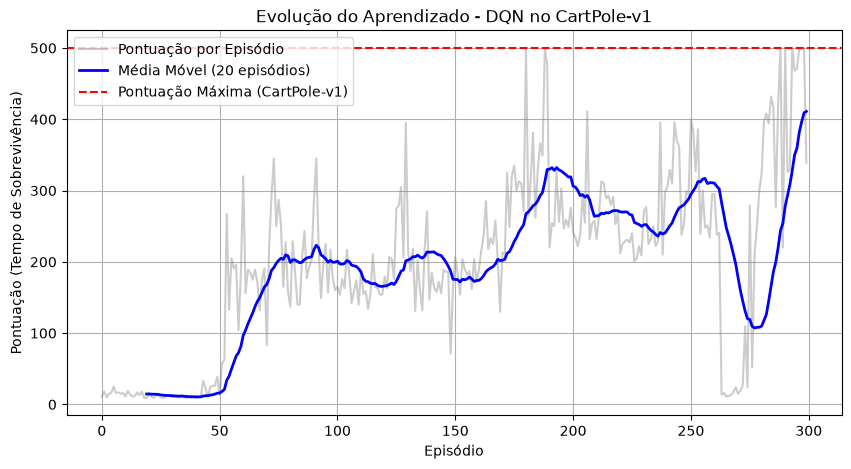

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(scores, label="Pontuação por Episódio", alpha=0.4, color="gray")

# Média móvel de 20 episódios
moving_avg = np.convolve(scores, np.ones(20) / 20, mode="valid")
plt.plot(
    range(19, len(scores)),
    moving_avg,
    label="Média Móvel (20 episódios)",
    color="blue",
    linewidth=2,
)

plt.axhline(
    y=500, color="r", linestyle="--", label="Pontuação Máxima (CartPole-v1)"
)
plt.title("Evolução do Aprendizado - DQN no CartPole-v1")
plt.xlabel("Episódio")
plt.ylabel("Pontuação (Tempo de Sobrevivência)")
plt.legend()
plt.grid(True)
plt.show()


Iniciando treinamento — epsilon_decay=0.99 (decai mais rápido)
  Episódio 20/300 | Pontuação Média (Últimos 20): 13.9 | Epsilon: 0.114
  Episódio 40/300 | Pontuação Média (Últimos 20): 12.2 | Epsilon: 0.010
  Episódio 60/300 | Pontuação Média (Últimos 20): 17.5 | Epsilon: 0.010
  Episódio 80/300 | Pontuação Média (Últimos 20): 115.1 | Epsilon: 0.010
  Episódio 100/300 | Pontuação Média (Últimos 20): 291.8 | Epsilon: 0.010
  Episódio 120/300 | Pontuação Média (Últimos 20): 166.3 | Epsilon: 0.010
  Episódio 140/300 | Pontuação Média (Últimos 20): 144.0 | Epsilon: 0.010
  Episódio 160/300 | Pontuação Média (Últimos 20): 138.7 | Epsilon: 0.010
  Episódio 180/300 | Pontuação Média (Últimos 20): 112.0 | Epsilon: 0.010
  Episódio 200/300 | Pontuação Média (Últimos 20): 119.6 | Epsilon: 0.010
  Episódio 220/300 | Pontuação Média (Últimos 20): 109.7 | Epsilon: 0.010
  Episódio 240/300 | Pontuação Média (Últimos 20): 115.5 | Epsilon: 0.010
  Episódio 260/300 | Pontuação Média (Últimos 20): 112.

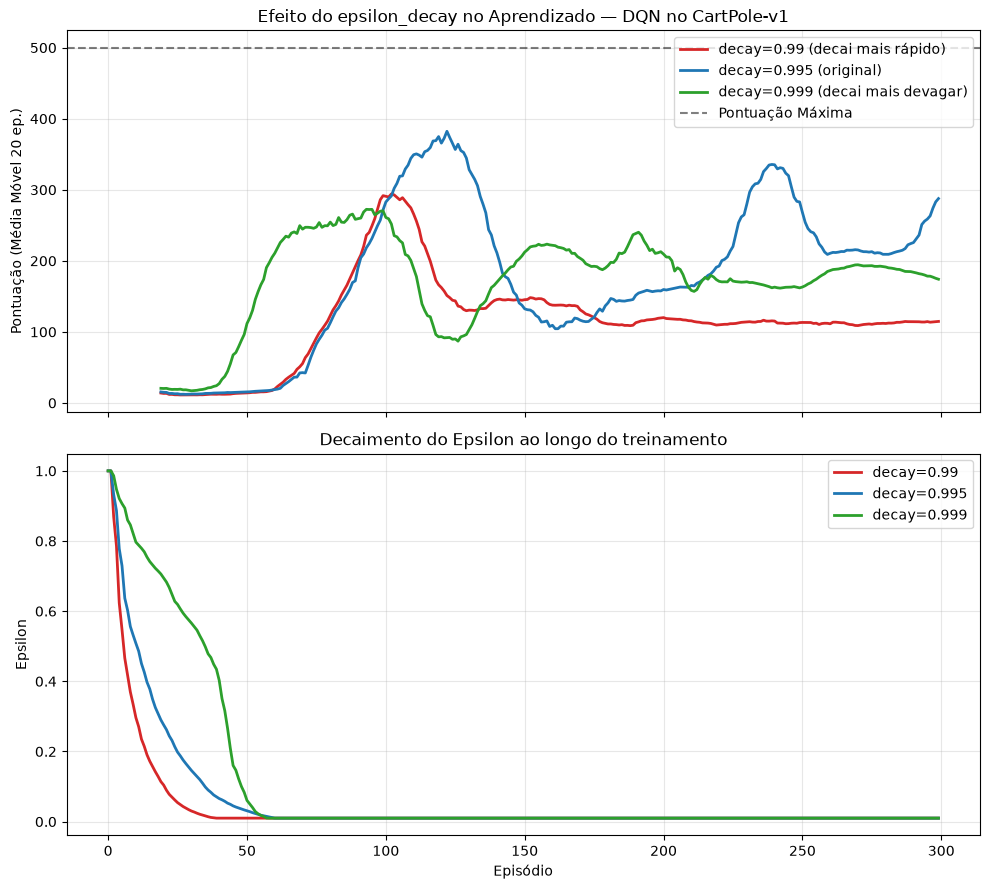

In [2]:
import random
from collections import deque

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

SEED = 67


class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
        )

    def forward(self, x):
        return self.fc(x)


class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        state, action, reward, next_state, done = zip(
            *random.sample(self.buffer, batch_size)
        )
        return (
            torch.FloatTensor(np.array(state)),
            torch.LongTensor(action),
            torch.FloatTensor(reward),
            torch.FloatTensor(np.array(next_state)),
            torch.FloatTensor(done),
        )

    def __len__(self):
        return len(self.buffer)


class DQNAgent:
    def __init__(
        self,
        state_dim,
        action_dim,
        gamma=0.99,
        lr=1e-3,
        batch_size=64,
        epsilon_start=1.0,
        epsilon_end=0.01,
        epsilon_decay=0.995,
    ):
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size

        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay

        self.policy_net = QNetwork(state_dim, action_dim)
        self.target_net = QNetwork(state_dim, action_dim)
        self.target_net.load_state_dict(self.policy_net.state_dict())

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayBuffer()

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)

        state_t = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = self.policy_net(state_t)
        return torch.argmax(q_values).item()

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return

        states, actions, rewards, next_states, dones = self.memory.sample(
            self.batch_size
        )

        q_values = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            max_next_q_values = self.target_net(next_states).max(1)[0]
            target_q_values = rewards + (1 - dones) * self.gamma * max_next_q_values

        loss = nn.MSELoss()(q_values, target_q_values)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())


def train(epsilon_decay, episodes=300, target_update_freq=10, verbose_label=""):
    # Reseta as sementes a cada rodada para que a ÚNICA diferença entre
    # os testes seja o epsilon_decay (mesma inicialização de rede,
    # mesmo replay buffer, mesmas transições do ambiente)
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    env = gym.make("CartPole-v1")
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = DQNAgent(state_dim, action_dim, epsilon_decay=epsilon_decay)
    scores = []
    epsilons = []

    print(f"\nIniciando treinamento — epsilon_decay={epsilon_decay} ({verbose_label})")

    for episode in range(1, episodes + 1):
        state, _ = env.reset(seed=SEED + episode)
        total_reward = 0
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.memory.push(state, action, reward, next_state, float(done))
            agent.train_step()

            state = next_state
            total_reward += reward

        scores.append(total_reward)
        epsilons.append(agent.epsilon)

        if episode % target_update_freq == 0:
            agent.update_target_network()

        if episode % 20 == 0:
            avg_score = np.mean(scores[-20:])
            print(
                f"  Episódio {episode}/{episodes} | Pontuação Média (Últimos 20):"
                f" {avg_score:.1f} | Epsilon: {agent.epsilon:.3f}"
            )

    env.close()
    return scores, epsilons


# ---------------------------------------------------------------------------
# Configurações a comparar
# ---------------------------------------------------------------------------
configs = [
    (0.99, "decai mais rápido"),
    (0.995, "original"),
    (0.999, "decai mais devagar"),
]

results = {}
for decay, label in configs:
    scores, epsilons = train(decay, verbose_label=label)
    results[decay] = {"scores": scores, "epsilons": epsilons, "label": label}

# Salva os dados brutos para reuso futuro (evita ter que retreinar de novo)
# Usa caminho relativo: salva na mesma pasta onde o script está sendo executado
np.savez(
    "resultados_epsilon_decay.npz",
    **{
        f"scores_{decay}".replace(".", "_"): results[decay]["scores"]
        for decay, _ in configs
    },
    **{
        f"epsilons_{decay}".replace(".", "_"): results[decay]["epsilons"]
        for decay, _ in configs
    },
)

# ---------------------------------------------------------------------------
# Gráfico comparativo: Pontuação (média móvel) + Epsilon
# ---------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

colors = {0.99: "tab:red", 0.995: "tab:blue", 0.999: "tab:green"}

for decay, _ in configs:
    scores = results[decay]["scores"]
    label = results[decay]["label"]
    moving_avg = np.convolve(scores, np.ones(20) / 20, mode="valid")
    ax1.plot(
        range(19, len(scores)),
        moving_avg,
        label=f"decay={decay} ({label})",
        color=colors[decay],
        linewidth=2,
    )

ax1.axhline(y=500, color="black", linestyle="--", alpha=0.5, label="Pontuação Máxima")
ax1.set_ylabel("Pontuação (Média Móvel 20 ep.)")
ax1.set_title("Efeito do epsilon_decay no Aprendizado — DQN no CartPole-v1")
ax1.legend()
ax1.grid(True, alpha=0.3)

for decay, _ in configs:
    epsilons = results[decay]["epsilons"]
    ax2.plot(
        epsilons,
        label=f"decay={decay}",
        color=colors[decay],
        linewidth=2,
    )

ax2.set_xlabel("Episódio")
ax2.set_ylabel("Epsilon")
ax2.set_title("Decaimento do Epsilon ao longo do treinamento")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("comparacao_epsilon_decay.png", dpi=150)
print("\nGráfico salvo em comparacao_epsilon_decay.png")
plt.show()